In [1]:
! uv pip install seaborn morethemes pyfonts pypalettes drawarrow dayplot contextily geopandas tqdm imageio

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Resolved 43 packages in 1.15s
Prepared 2 packages in 298ms
Installed 13 packages in 272ms
 + affine==2.4.0
 + cligj==0.7.2
 + contextily==1.7.0
 + dayplot==0.5.1
 + drawarrow==0.1.0
 + geographiclib==2.1
 + geopy==2.4.1
 + imageio==2.37.3
 + mercantile==1.2.1
 + morethemes==0.5.1
 + pyfonts==1.3.0
 + pypalettes==0.2.1
 + rasterio==1.5.0


TASKS

- les "Cat-Nat stripes" mais avec le nombre de commune touchées plutôt que le nombre de Cat-Nat
- la part des communes qui a déjà été touchées par une cat nat (les moyennes mobiles sur 5 et 10 ans pour comparer ça serait pas mal)
- pour l'instant il y a un camembert sur la couverture PPRN des arrêtés reconnus, on aimerait l'avoir par risque (inondation, RGA et autres) si c'est possible
- Nombre de communes touchées par un arrêté cat-nat reconnu VS non reconnu (par an) (+ idem mais comptabilisé en population)


# IMPORT


In [3]:
import duckdb

# The usual suspects
import numpy as np
import pandas as pd

# Chart and Figure
import seaborn as sns
import matplotlib
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Fonts, Palettes, Themes, Arrow (https://github.com/y-sunflower)
# Strong inspiration: https://www.yan-holtz.com/
import morethemes as mt
from pyfonts import load_google_font, load_font
from pypalettes import load_palette, load_cmap
from drawarrow import fig_arrow
import dayplot as dp  # Calendar plot for timeseries

# GeoSpatial
import contextily as ctx
from shapely.affinity import translate, scale
import geopandas as gpd

# GIF
import imageio
from tqdm import tqdm

# Removing warnings
import warnings

warnings.filterwarnings("ignore")

# LOAD DATA


In [5]:
# Setup
font = load_google_font(
    "Montserrat", italic=False
)  # check here: https://fonts.google.com/
# mt.set_theme("nature")

source_text = (
    "Source: CCR (Caisse Centrale de Réassurance)"  # Main Source for the analysis
)

In [18]:
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"
communes_geo = gpd.read_file(communes_geojson_url)

In [ ]:
con = duckdb.connect(database="dev.duckdb", read_only=True)

In [ ]:
query_ccr_main = """
SELECT
	*
FROM dev.main.ccr_main_page
"""

ccr_main = con.sql(query_ccr_main)
ccr_main_df = ccr_main.df()
ccr_main_df.head(2)

In [ ]:
query_ccr_details = """
					SELECT
						*
					FROM dev.main.ccr_details
					"""

ccr_details = con.sql(query_ccr_details)
ccr_details_df = ccr_details.df()
ccr_details_df = ccr_details_df[
    ~ccr_details_df.duplicated(subset=["code_geo", "code_arrete"])
]
ccr_details_df.head(2)

# GRAPHS


In [ ]:
main_data_occur_total = ccr_main_df.groupby("date_arrete").size()

ccr_main_df["nom_peril"] = (
    ccr_main_df["nom_peril"]
    .mask(ccr_main_df["nom_peril"].str.contains("Inondations"), "Inondations")
    .where(ccr_main_df["nom_peril"].str.contains("Inondations|Sécheresse"), "Autre")
)

main_data_occur_inond = (
    ccr_main_df[ccr_main_df["nom_peril"] == "Inondations"].groupby("date_arrete").size()
)
main_data_occur_secheresse = (
    ccr_main_df[ccr_main_df["nom_peril"] == "Sécheresse"].groupby("date_arrete").size()
)

In [25]:
details_par_catnat = ccr_details_df.copy()

details_par_catnat["date_arrete"] = pd.to_datetime(details_par_catnat["date_arrete"])
details_par_catnat["libelle_avis"] = details_par_catnat["libelle_avis"].replace(
    {"Reconnue(sans impact sur la modulation)": "Reconnue"}
)

details_par_catnat["nom_peril"] = (
    details_par_catnat["nom_peril"]
    .mask(details_par_catnat["nom_peril"].str.contains("Inondations"), "Inondations")
    .where(
        details_par_catnat["nom_peril"].str.contains("Inondations|Sécheresse"), "Autre"
    )
)

details_par_catnat = details_par_catnat[
    (details_par_catnat["date_arrete"].dt.year > 1983)
    & (details_par_catnat["date_arrete"].dt.year < 2026)
]
details_par_catnat["periode_2010"] = np.where(
    details_par_catnat["date_arrete"].dt.year < 2010, "Avant 2010", "Après 2010"
)

avis_par_catnat = (
    details_par_catnat.groupby(
        [
            pd.Grouper(key="date_arrete", freq="YE"),
            "nom_peril",
            "libelle_avis",
            "periode_2010",
        ]
    )
    .size()
    .reset_index(name="count")
)

## STRIP CATNAT


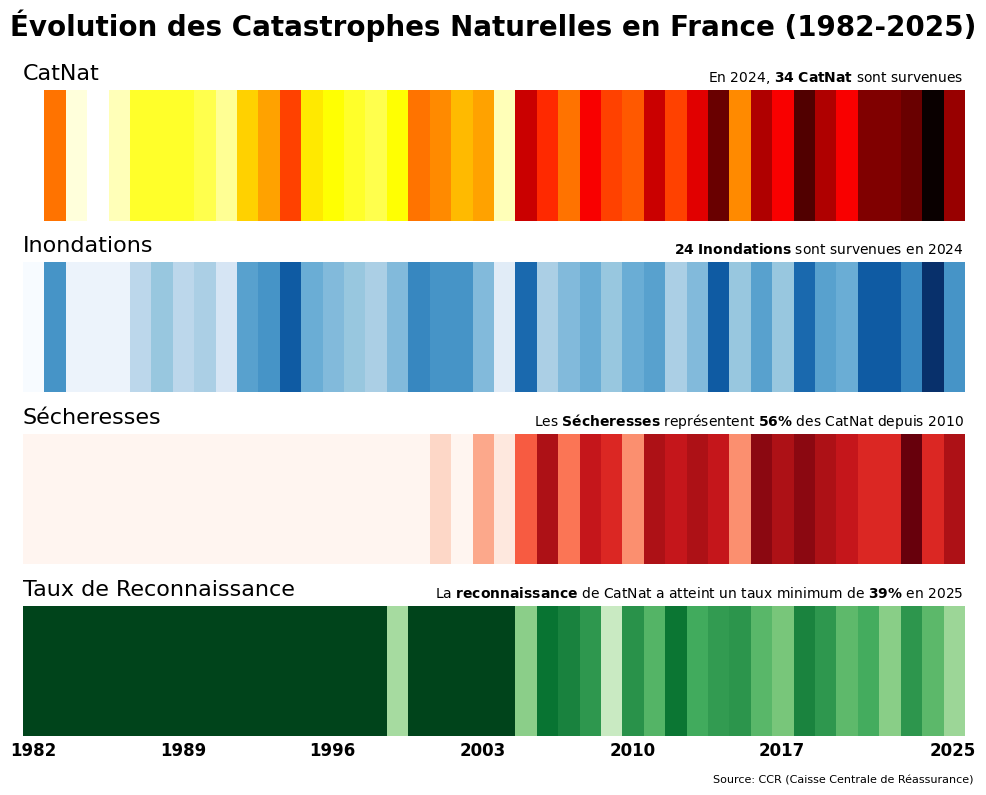

In [27]:
annual_counts = main_data_occur_total.loc[:"2025"].resample("YE").sum()
annual_counts_inond = main_data_occur_inond.loc[:"2025"].resample("YE").sum()
annual_counts_secheresse = main_data_occur_secheresse.loc[:"2025"].resample("YE").sum()

# Recon
recon = ccr_details_df.copy()
recon = (
    recon.groupby([ccr_details_df["date_arrete"].dt.year, "libelle_avis"])
    .size()
    .unstack(fill_value=0)
)

recon["ratio_recon"] = (recon["Reconnue"] / recon.sum(axis=1)) * 100


all_years = annual_counts.index

data_total = annual_counts.values.reshape(1, -1)
data_inond = annual_counts_inond.reindex(all_years, fill_value=0).values.reshape(1, -1)
data_sech = annual_counts_secheresse.reindex(all_years, fill_value=0).values.reshape(
    1, -1
)
data_recon = recon["ratio_recon"].loc[:"2025"].values.reshape(1, -1)


fig, axs = plt.subplots(nrows=4, figsize=(10, 8))

# CatNat
img = axs[0].imshow(data_total, cmap="hot_r", aspect="auto", interpolation="nearest")
axs[0].set_axis_off()

axs[0].set_title("CatNat", loc="left", pad=7.5, fontsize=16, color="black")

# Inondations
img = axs[1].imshow(data_inond, cmap="Blues", aspect="auto", interpolation="nearest")
axs[1].set_axis_off()

axs[1].set_title("Inondations", loc="left", pad=7.5, fontsize=16, color="black")

# Sécheresse
img = axs[2].imshow(data_sech, cmap="Reds", aspect="auto", interpolation="nearest")
axs[2].set_axis_off()

axs[2].set_title("Sécheresses", loc="left", pad=7.5, fontsize=16, color="black")

# Recon
img = axs[3].imshow(
    data_recon, cmap="Greens", aspect="auto", interpolation="nearest", vmin=0, vmax=100
)

axs[3].set_title(
    "Taux de Reconnaissance", loc="left", pad=7.5, fontsize=16, color="black"
)

# Axis
tick_indices = np.linspace(0, len(all_years) - 1, 7, dtype=int)

axs[3].set_xticks(tick_indices)
axs[3].set_xticklabels(
    [all_years.year[i] for i in tick_indices],
    fontsize=12,
    fontweight="bold",
    color="black",
)

axs[3].tick_params(axis="x", which="both", length=0)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])

# Titles and  Annotations
plt.suptitle(
    "Évolution des Catastrophes Naturelles en France (1982-2025)",
    color="black",
    fontsize=20,
    fontweight="bold",
    y=0.99,
)

axs[0].text(
    1,
    1.1,
    r"En 2024, $\bf{34}$ $\bf{CatNat}$ sont survenues",
    transform=axs[0].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[1].text(
    1,
    1.1,
    r"$\bf{24}$ $\bf{Inondations}$ sont survenues en 2024",
    transform=axs[1].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[2].text(
    1,
    1.1,
    r"Les $\bf{Sécheresses}$ représentent $\bf{56\%}$ des CatNat depuis 2010",
    transform=axs[2].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[3].text(
    1,
    1.1,
    r"La $\bf{reconnaissance}$ de CatNat a atteint un taux minimum de $\bf{39\%}$ en 2025",
    transform=axs[3].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

plt.text(
    1.01,
    -0.375,
    source_text,
    ha="right",
    va="bottom",
    transform=axs[3].transAxes,
    fontsize=8,
    color="black",
)

plt.savefig(
    "CatNat_Stripes_Vector.pdf", facecolor=fig.get_facecolor(), bbox_inches="tight"
)

plt.tight_layout()
plt.savefig(
    "Evolution_CatNat_France_1982_2025.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.5,
)

plt.show()


## STACKED AREA


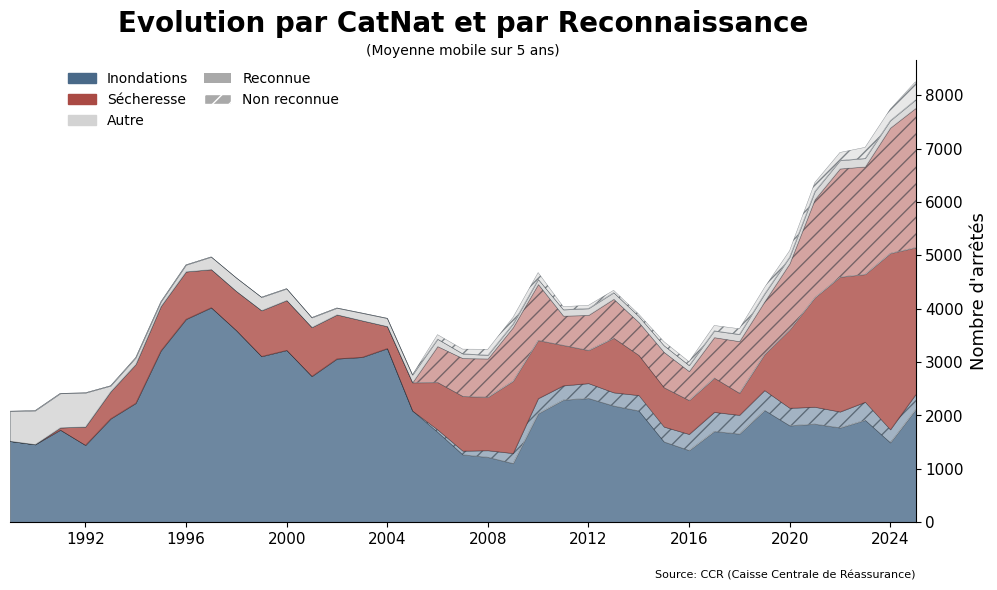

In [43]:
def stacked_area_type_catnat(
    df,
    font=None,
    target_col="libelle_avis",
    hatch="//",
    limit_years=[1984, 2025],
    window=3,
):

    df_plot = df.copy()
    if target_col == "libelle_avis":
        title = "Evolution par CatNat et par Reconnaissance"
        status_request = "Non reconnue"

        custom_order = [
            "Reconnue,Inondations",
            "Non reconnue,Inondations",
            "Reconnue,Sécheresse",
            "Non reconnue,Sécheresse",
            "Reconnue,Autre",
            "Non reconnue,Autre",
        ]
    else:
        df_plot["franchise"] = np.where(
            df_plot["franchise"] == "Simple", "Simple", "Doublée ou plus"
        )
        title = "Evolution par CatNat et par Franchise"
        status_request = "Doublée ou plus"

        custom_order = [
            "Simple,Inondations",
            "Doublée ou plus,Inondations",
            "Simple,Sécheresse",
            "Doublée ou plus,Sécheresse",
            "Simple,Autre",
            "Doublée ou plus,Autre",
        ]

    df_plot = df.pivot_table(
        index="date_arrete",
        columns=[target_col, "nom_peril"],
        values="count",
        aggfunc="sum",
    ).fillna(0)

    df_plot = df_plot.rolling(window=window, center=False).mean()

    new_columns = [(c.split(",")[0], c.split(",")[1]) for c in custom_order]
    df_plot = df_plot[new_columns]

    _, ax = plt.subplots(figsize=(10, 6))

    x = df_plot.index
    y_values = [df_plot[col] for col in df_plot.columns]
    labels = [f"{p} ({s})" for s, p in df_plot.columns]

    layers = ax.stackplot(
        x,
        y_values,
        labels=labels,
        alpha=0.8,
        colors=["#496988", "#496988", "#AA4A44", "#AA4A44", "lightgrey", "lightgrey"],
        edgecolor="#19242E",
        linewidth=0.3,
    )

    for i, (status, peril) in enumerate(df_plot.columns):
        if status == status_request:
            layers[i].set_hatch(hatch)
            layers[i].set_alpha(0.5)

    peril_handles = [
        mpatches.Patch(color="#496988", label="Inondations"),
        mpatches.Patch(color="#AA4A44", label="Sécheresse"),
        mpatches.Patch(color="lightgrey", label="Autre"),
    ]

    status_handles = [
        mpatches.Patch(
            facecolor="darkgrey",
            label="Reconnue" if target_col == "libelle_avis" else "Simple",
        ),
        mpatches.Patch(
            facecolor="darkgrey",
            hatch=hatch,
            edgecolor="white",
            label="Non reconnue" if target_col == "libelle_avis" else "Doublée ou plus",
        ),
    ]

    legend_peril = ax.legend(
        handles=peril_handles,
        loc="upper left",
        bbox_to_anchor=(0.05, 1),
        title="",
        prop=font,
        fontsize=10,
        labelcolor="black",
        frameon=False,
    )
    ax.add_artist(legend_peril)

    ax.legend(
        handles=status_handles,
        loc="upper left",
        bbox_to_anchor=(0.2, 1),
        title="",
        prop=font,
        fontsize=10,
        labelcolor="black",
        frameon=False,
    )
    ax.grid(False)

    plt.title(title, font=font, fontsize=20, fontweight="bold", color="black", pad=20)
    plt.text(
        0.5,
        1.01,
        f"(Moyenne mobile sur {window} ans)",
        font=font,
        fontsize=10,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )

    ax.yaxis.set_ticks_position("right")
    ax.yaxis.set_label_position("right")

    ax.set_ylabel("Nombre d'arrêtés", font=font, fontsize=13, color="black")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.yaxis.set_label_coords(1.06, 0.5)

    plt.yticks(font=font, fontsize=11)
    plt.xticks(font=font, fontsize=11)

    plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    x_start = pd.to_datetime(str(limit_years[0] + window))
    x_end = pd.to_datetime(str(limit_years[1]))
    plt.xlim([x_start, x_end])
    plt.tight_layout()

    return ax


stacked_area_type_catnat(df=avis_par_catnat, window=5);

## Augmentation CatNat Map


In [ ]:
def prepare_france_geometry(df):
    if df.crs != "EPSG:2154":
        df = df.to_crs(epsg=2154)

    df["dept_temp"] = df["code"].apply(lambda x: x[:3] if x.startswith("97") else x[:2])

    drom_configs = {
        "971": {"pos": (-150000, 6540000), "scale": 1.3, "name": "Guadeloupe"},
        "972": {"pos": (50000, 6540000), "scale": 1.8, "name": "Martinique"},
        "973": {"pos": (-150000, 6140000), "scale": 0.25, "name": "Guyane"},
        "974": {"pos": (-150000, 6340000), "scale": 1, "name": "La Réunion"},
        "976": {"pos": (50000, 6340000), "scale": 2.5, "name": "Mayotte"},
    }

    df_main = df[~df["dept_temp"].str.startswith("97")].copy()
    df_droms = []

    for code, cfg in drom_configs.items():
        drom = df[df["dept_temp"] == code].copy()
        if not drom.empty:
            centroid = drom.geometry.unary_union.centroid
            drom.geometry = drom.geometry.translate(xoff=-centroid.x, yoff=-centroid.y)
            drom.geometry = drom.geometry.scale(
                xfact=cfg["scale"], yfact=cfg["scale"], origin=(0, 0)
            )

            # Box Position
            drom.geometry = drom.geometry.translate(
                xoff=cfg["pos"][0], yoff=cfg["pos"][1]
            )
            df_droms.append(drom)

    return gpd.pd.concat([df_main] + df_droms), drom_configs


def monovariate_map(
    df,
    col="taux_non_rec_global",
    cmap="copper_r",
    title="Taux de non-reconnaissance par commune",
    missing_color="white",
    norm=None,
    legend_label="(%)",
    subtitle=None,
    linewidth=0.1,
    colorbar=True,
):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        legend=colorbar,
        legend_kwds={"shrink": 0.4, "pad": -0.05},
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth,
    )

    cbar_ax = ax.get_figure().get_axes()[-1]
    cbar_ax.set_ylabel(f" {legend_label}", color="black")

    if subtitle:
        ax.text(
            0.5,
            0.99,
            subtitle,
            transform=ax.transAxes,
            fontsize=14,
            color="dimgray",
            ha="center",
            style="italic",
        )

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000

    for code, cfg in drom_configs.items():
        x, y = cfg["pos"]
        rect = mpatches.Rectangle(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            linewidth=0.5,
            edgecolor="gray",
            facecolor="none",
            linestyle="--",
            alpha=0.6,
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(
            x,
            y + (box_h / 2) + 12500,
            cfg["name"],
            fontsize=9,
            ha="center",
            color="dimgray",
        )

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight="bold", pad=15, color="black")

    null_patch = mpatches.Patch(
        color=missing_color, label="Pas de cas", edgecolor="black"
    )
    leg = ax.legend(
        handles=[null_patch],
        loc="lower left",
        frameon=False,
        bbox_to_anchor=(0.5, 0.025),
    )

    plt.setp(leg.get_texts(), color="black", fontsize=10)

    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig

In [ ]:
def per_period(
    df,
    bins=[1984, 2010, 2026],
    labels=["pre_2010", "post_2010"],
):
    years_pre = bins[1] - bins[0]
    years_post = bins[2] - bins[1]

    period_data = df.copy()
    period_data["period"] = pd.cut(
        period_data["date_debut_evenement"].dt.year,
        bins=bins,
        labels=labels,
        right=False,
    )

    counts = period_data.groupby(["code_geo", "period"]).size().unstack(fill_value=0)

    counts["freq_pre"] = counts[labels[0]] / years_pre
    counts["freq_post"] = counts[labels[1]] / years_post

    counts["freq_growth"] = (
        (counts["freq_post"] - counts["freq_pre"]) / (counts["freq_pre"] + 0.01)
    ) * 100

    return counts


period_stats = per_period(ccr_details_df)
nb_diff_geo = communes_geo.merge(
    period_stats, left_on="code", right_index=True, how="left"
)

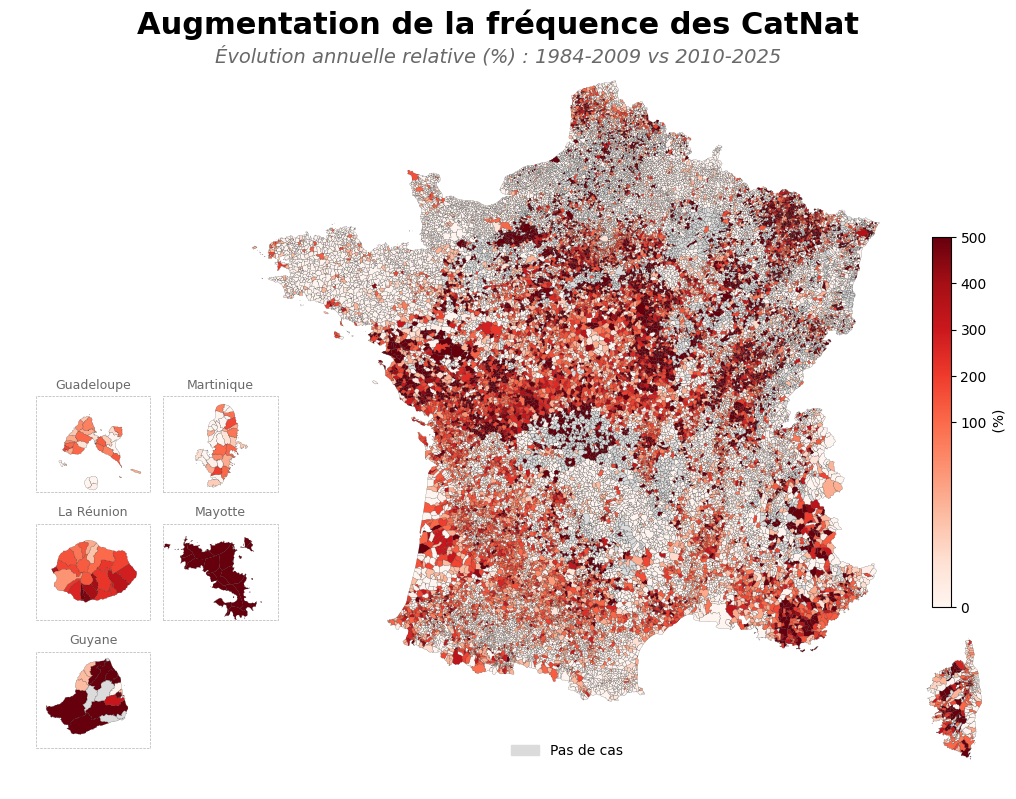

In [ ]:
missing_color = "#DBDBDB"

vmin, vcenter, vmax = 0, 100, 500
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

monovariate_map(
    nb_diff_geo,
    col="freq_growth",
    cmap="Reds",
    norm=norm,
    title="Augmentation de la fréquence des CatNat",
    missing_color=missing_color,
    subtitle="Évolution annuelle relative (%) : 1984-2009 vs 2010-2025",
);

## PPRN Couverture RGA


## DONUT PPRN


## TASK - 1: Stripe Communes


## TASK - 2: Moyenne mobile communes touchées


## TASK - 3: Couverture PPRN par risques


## TASK - 4: Communes catnat reconnu VS non reconnu (par an)
